# Concrete Compressive Strength Prediction

## 1. Problem Statement

The objective of this project is to predict the compressive strength of concrete using its material composition and curing age.

Concrete strength is influenced by several factors such as cement content, water content, aggregates, supplementary materials, and curing time. By analyzing these factors, we aim to build a machine learning model capable of accurately estimating concrete compressive strength.

## Project Workflow

1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Data Preprocessing
7. Model Building
8. Model Evaluation

## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2.1 Data Collection
- Dataset Source - https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength
- This data consists of 9 columns and 1030 rows

## Import the XLS Data as a Pandas DataFrame

In [3]:
df = pd.read_excel('/content/Concrete_Data.xls')

## Renaming the columns

In [4]:
df.columns = [
    'Cement',
    'Blast_Furnace_Slag',
    'Fly_Ash',
    'Water',
    'Superplasticizer',
    'Coarse_Aggregate',
    'Fine_Aggregate',
    'Age',
    'Strength'
]

## Show Top 5 Records

In [5]:
df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## Shape of the dataset

In [6]:
df.shape

(1030, 9)

## 2.2 Dataset information

## 1. Cement (kg/m³)
- Amount of cement used in the concrete mixture.
- Cement is the primary binding material that holds the concrete together.
- Generally, increasing cement content tends to increase concrete strength.
- Unit: kilograms per cubic meter (kg/m³).

## 2. Blast Furnace Slag (kg/m³)
- Industrial by-product obtained during steel production.
- Often used as a partial replacement for cement.
- Can improve durability and long-term strength of concrete.
- Unit: kg/m³.

## 3. Fly Ash (kg/m³)
- Fine powder produced from coal combustion.
- Used as a supplementary cementitious material.
- Helps improve workability and long-term performance of concrete.
- Unit: kg/m³.

## 4. Water (kg/m³)
- Amount of water used in the concrete mix.
- Required for the chemical reaction that hardens cement.
- Excess water can reduce concrete strength by creating pores.
- Unit: kg/m³.

## 5. Superplasticizer (kg/m³)
- Chemical additive used to improve the flowability of concrete.
- Allows reduction in water content while maintaining workability.
- Often contributes indirectly to higher concrete strength.
- Unit: kg/m³.

## 6. Coarse Aggregate (kg/m³)
- Large particles such as crushed stone or gravel.
- Provides structural support and bulk to the concrete.
- Plays an important role in the overall stability of the mixture.
- Unit: kg/m³.

## 7. Fine Aggregate (kg/m³)
- Fine particles, typically sand.
- Fills spaces between coarse aggregates.
- Improves density, workability, and compactness of concrete.
- Unit: kg/m³.

## 8. Age (Days)
- Number of days the concrete was allowed to cure before testing.
- Not an ingredient, but a time-related feature.
- Concrete generally gains strength as curing time increases.
- Unit: Days.

## 9. Concrete Compressive Strength (MPa) - Target Variable
- Measures the maximum compressive load the concrete can withstand before failure.
- Represents the strength of the concrete sample.
- This is the variable that machine learning models attempt to predict.
- Unit: Megapascals (MPa).

# Business Understanding

The objective of this dataset is to predict the **compressive strength of concrete** based on the quantities of materials used in the mixture and the curing age.

Such predictions can help engineers estimate concrete performance without performing expensive and time-consuming laboratory tests for every new mix design.

The dataset captures the relationship:

**Concrete Ingredients + Curing Age → Concrete Compressive Strength**

Where:
- Concrete ingredients represent the composition of the mixture.
- Curing age represents the time allowed for the concrete to harden.
- Compressive strength represents the final strength achieved by the concrete sample.


## 3. Data Checks to perform
- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

 ## 3.1 Check Missing Values


In [7]:
df.isna().sum()

,0
Cement,0
Blast_Furnace_Slag,0
Fly_Ash,0
Water,0
Superplasticizer,0
Coarse_Aggregate,0
Fine_Aggregate,0
Age,0
Strength,0


#### There are no missing values in the data set

## 3.2 Check Duplicates

In [8]:
df.duplicated().sum()

np.int64(25)

#### Duplicate Records

The dataset contains 25 duplicate observations. Since these rows represent identical values across all features and the target variable, they do not contribute additional information to the analysis. Therefore, duplicate records were removed prior to model development.

In [9]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (1030, 9)
After: (1005, 9)


### 3.3 Check data types

In [10]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1005 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1005 non-null   float64
 1   Blast_Furnace_Slag  1005 non-null   float64
 2   Fly_Ash             1005 non-null   float64
 3   Water               1005 non-null   float64
 4   Superplasticizer    1005 non-null   float64
 5   Coarse_Aggregate    1005 non-null   float64
 6   Fine_Aggregate      1005 non-null   float64
 7   Age                 1005 non-null   int64  
 8   Strength            1005 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 78.5 KB


### 3.4 Checking the number of unique values in each column

In [11]:
df.nunique()

,0
Cement,280
Blast_Furnace_Slag,187
Fly_Ash,163
Water,205
Superplasticizer,155
Coarse_Aggregate,284
Fine_Aggregate,304
Age,14
Strength,938


### 3.5 Check statistics of data set

In [12]:
df.describe()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.629055,72.043134,55.535075,182.074378,6.031647,974.376468,772.686617,45.856716,35.250273
std,104.345003,86.170555,64.207448,21.340740,5.919559,77.579534,80.339851,63.734692,16.284808
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,190.680000,0.000000,0.000000,166.610000,0.000000,932.000000,724.300000,7.000000,23.523542
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.798114
75%,349.000000,142.500000,118.270000,192.940000,10.000000,1031.000000,822.200000,56.000000,44.868340
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


#### Key Observations
1. **Age exhibits the largest variability**, suggesting curing time may have a strong influence on compressive strength.
2. **Fly Ash and Blast Furnace Slag contain many zero values**, indicating these materials are optional components in many concrete mixtures.
3. **Water content varies relatively little**, suggesting it is carefully controlled during concrete production.
4. **Concrete strength shows substantial variation**, making this dataset suitable for a regression problem.
5. Several features appear right-skewed, particularly **Blast Furnace Slag**, **Fly Ash**, and **Age**, which may be worth investigating further through visualizations.

## 4. Exploring Data(Visualization)

### 4.1 Histogram

### Univariate Analysis

Histograms are used to understand the distribution of numerical features.

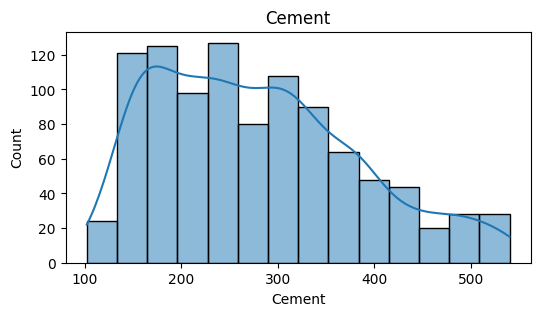

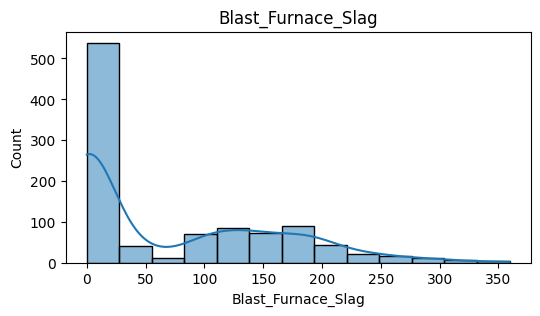

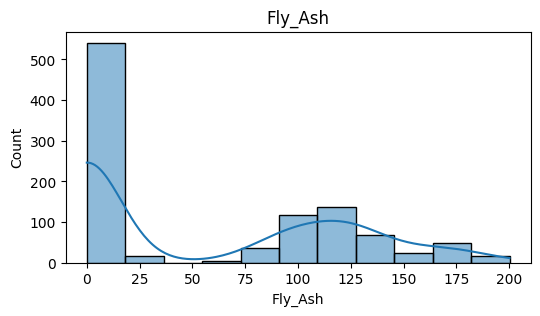

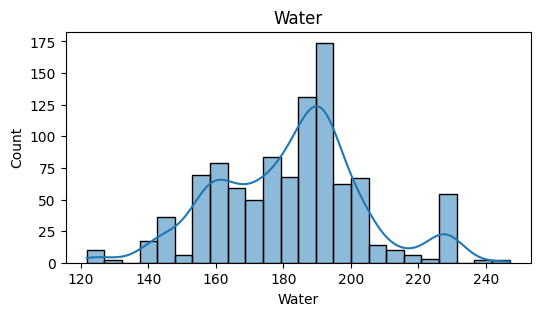

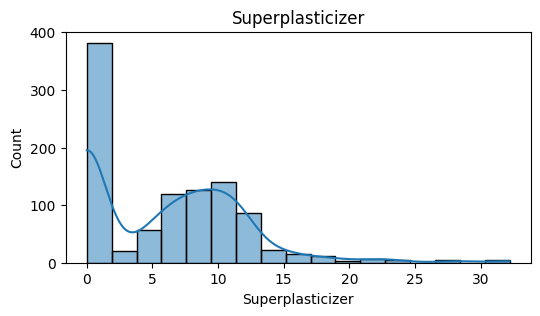

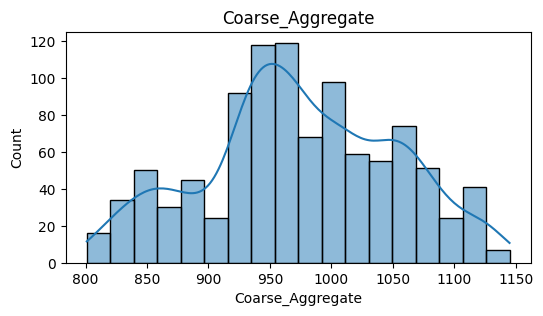

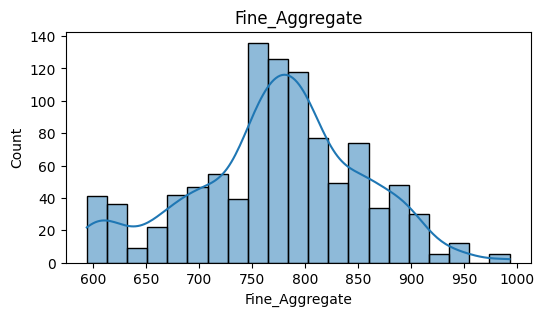

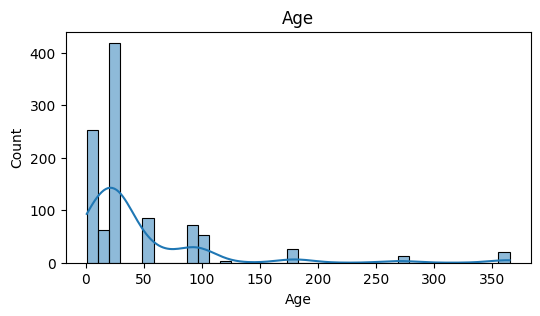

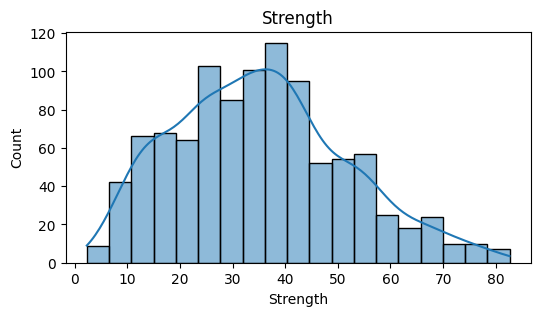

In [13]:
for col in df.columns:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

### Observations

- Age exhibits a right-skewed distribution.
- Fly Ash and Blast Furnace Slag are heavily right-skewed due to many zero values.
- Strength appears moderately distributed across a wide range of values.
- Some features contain extreme values, which will be further examined using boxplots.

### 4.2 Boxplot

### Outlier Analysis

Boxplots help identify potential outliers and understand feature spread.

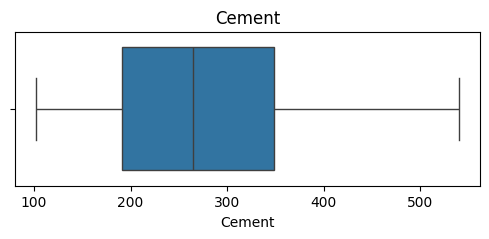

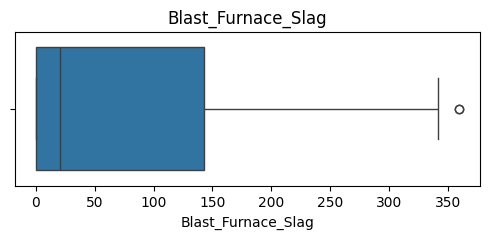

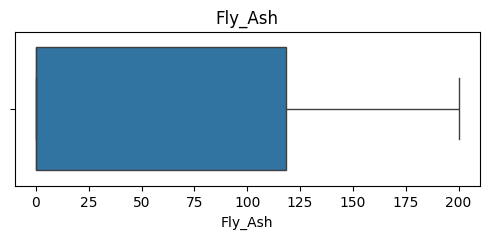

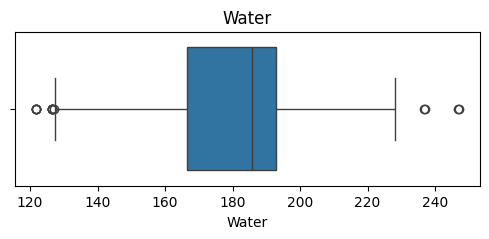

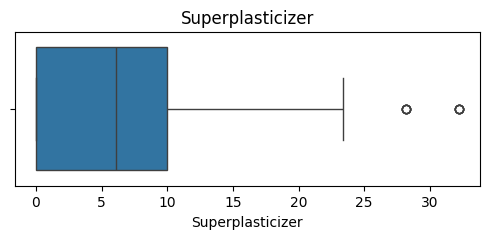

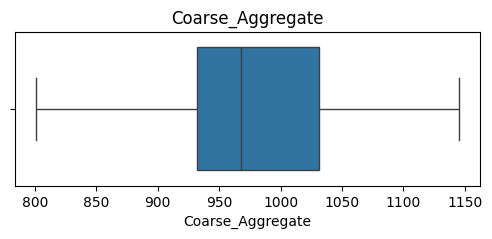

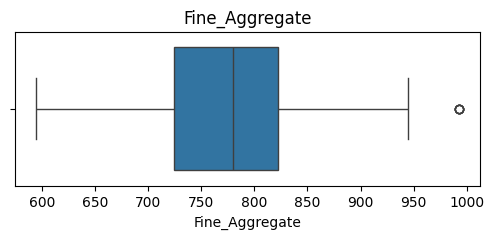

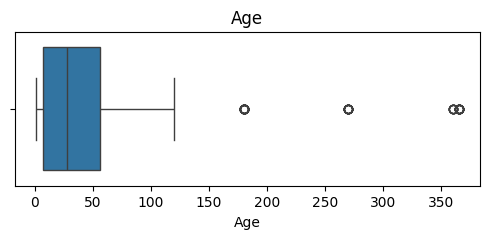

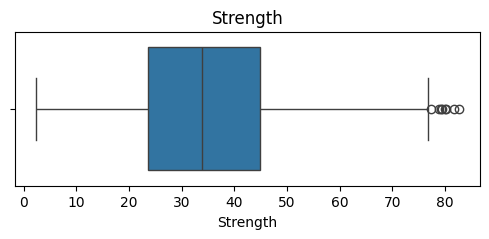

In [14]:
for col in df.columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Observations

Several features contain potential outliers.

However, these values appear to represent legitimate engineering measurements rather than data-entry errors.

For example, concrete samples cured for 365 days are uncommon but realistic.

Therefore, outliers are retained.

### 4.3 Scatter Plot

### Bivariate Analysis

Scatterplots are used to investigate relationships between each feature and the target variable.

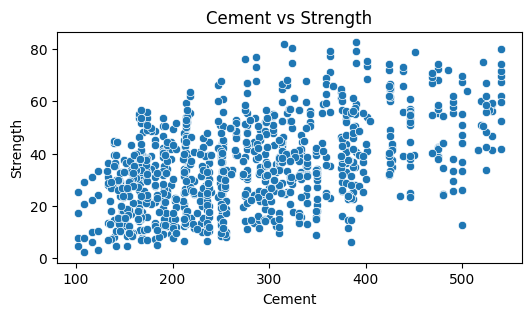

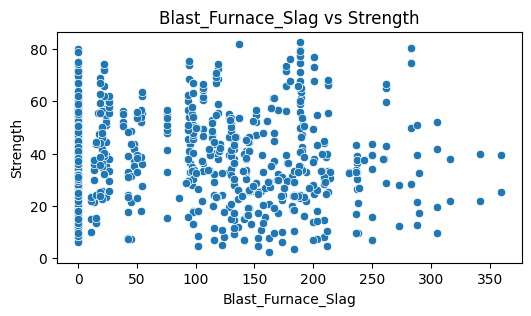

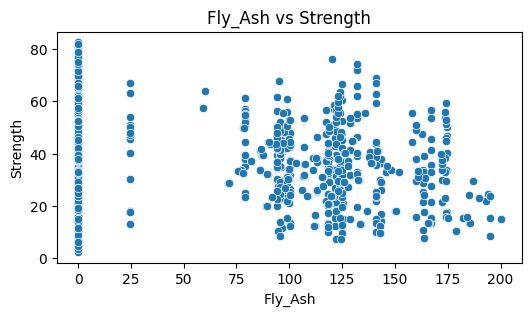

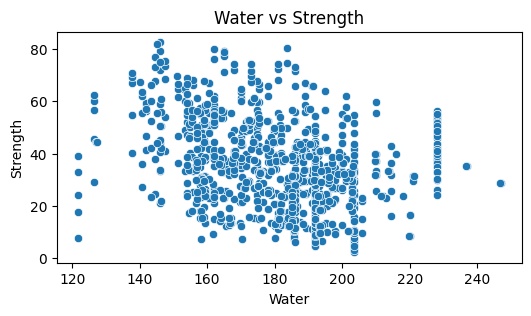

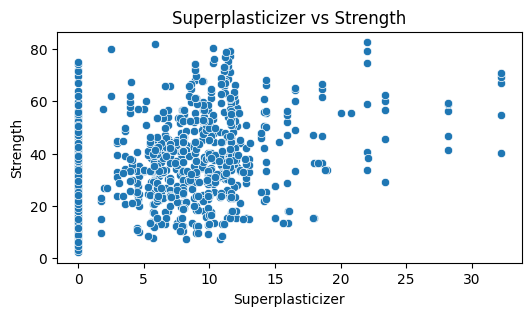

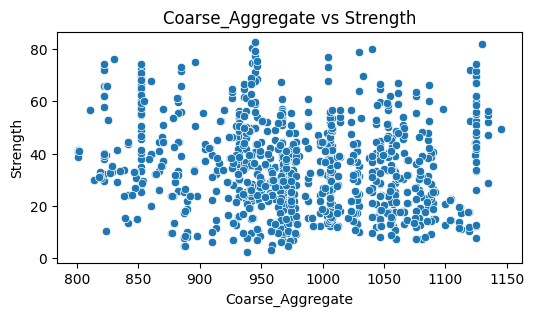

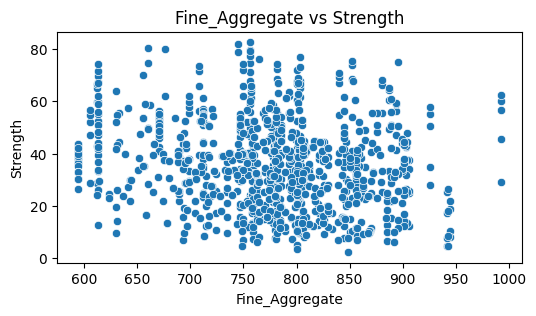

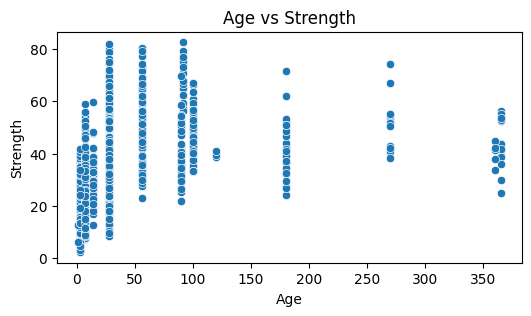

In [15]:
features = df.drop('Strength', axis=1).columns

for col in features:
    plt.figure(figsize=(6,3))
    sns.scatterplot(x=df[col], y=df['Strength'])
    plt.title(f'{col} vs Strength')
    plt.show()

### Observations

- Strength generally increases with Age.
- Higher Cement content tends to be associated with stronger concrete.
- Water exhibits a weak negative relationship with Strength.
- Several relationships appear non-linear, suggesting that machine learning models may capture patterns better than simple linear analysis.

### 4.4 Correlation Heatmap

### Correlation Analysis

Correlation measures the strength and direction of linear relationships between variables.

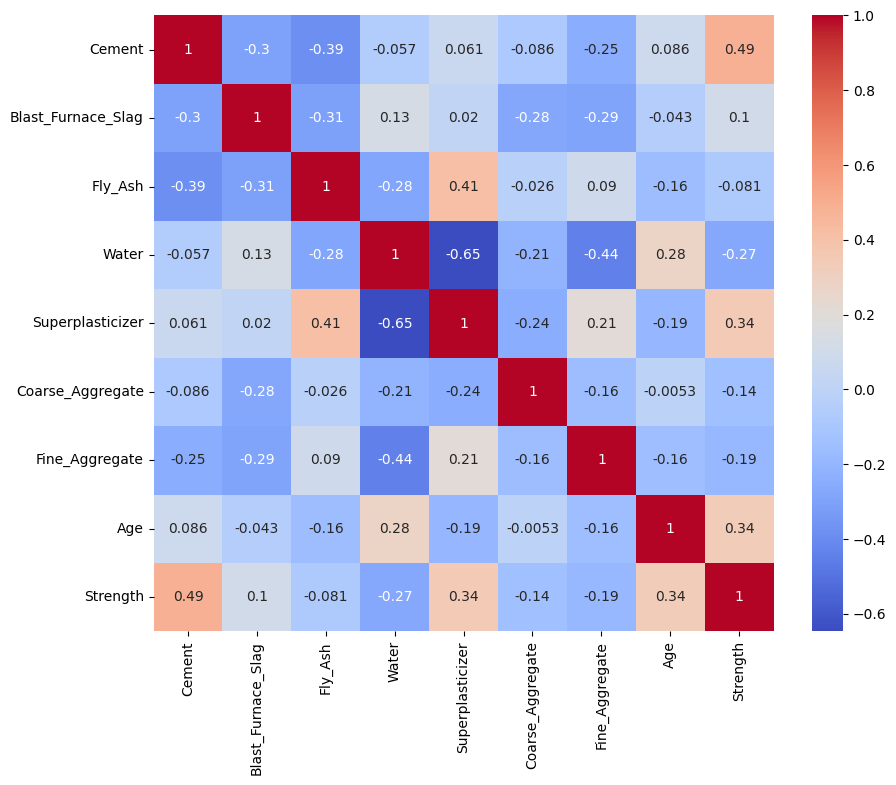

In [16]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [17]:
df.corr()['Strength'].sort_values(ascending=False)

,Strength
Strength,1.000000
Cement,0.488283
Superplasticizer,0.344225
Age,0.337371
Blast_Furnace_Slag,0.103370
Fly_Ash,-0.080648
Coarse_Aggregate,-0.144710
Fine_Aggregate,-0.186457
Water,-0.269606


### Correlation Insights

- Cement shows the strongest positive relationship with Strength.
- Superplasticizer and Age also demonstrate moderate positive relationships.
- Water exhibits a negative correlation, suggesting that excessive water may reduce strength.
- No feature individually dominates the target variable.

This indicates that compressive strength is influenced by a combination of factors rather than a single ingredient.

# EDA Summary

### Key Findings

1. Cement exhibits the strongest positive correlation with compressive strength.
2. Age plays an important role, with longer curing periods generally producing stronger concrete.
3. Water demonstrates a negative relationship with strength.
4. Several features exhibit skewed distributions, but the values appear realistic and were retained.
5. No single feature explains the target completely, indicating that strength depends on multiple interacting factors.
6. Feature engineering using Water-Cement Ratio may improve predictive performance.

The dataset appears clean and suitable for machine learning regression models.

# Model Training

## 1.1 Import Data and Required Packages

In [ ]:
pip install catboost

In [19]:
# Basic Import
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Modelling
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV,train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import warnings

## Import the XLS Data as Pandas DataFrame

In [20]:
df = pd.read_excel('/content/Concrete_Data.xls')

## Renaming the columns

In [21]:
df.columns=[
    'Cement',
    'Blast_Furnace_Slag',
    'Fly_Ash',
    'Water',
    'Superplasticizer',
    'Coarse_Aggregate',
    'Fine_Aggregate',
    'Age',
    'Strength'
]

## Show Top 5 Records

In [22]:
df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## Preparing X and y variables

In [23]:
X = df.drop(columns = ['Strength'],axis=1)

In [24]:
y = df['Strength']

In [25]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include = 'object').columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScaler',numeric_transformer,num_features),
    ]
    )

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size = 0.8,random_state=42)
X_train.shape,X_test.shape

((824, 8), (206, 8))

In [27]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Create an Evaluation Function to give all metrics after training

In [28]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [29]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42)
}

params = {
    "Linear Regression": {},

    "Ridge": {
        "alpha": [0.01, 0.1, 1, 10, 100]
    },

    "Lasso": {
        "alpha": [0.0001, 0.001, 0.01, 0.1, 1]
    },

    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    },

    "Decision Tree": {
        "max_depth": [None, 5, 10, 15, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "AdaBoost": {
        "n_estimators": [50, 100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1, 0.5, 1]
    },

    "SVR": {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto"],
        "kernel": ["rbf", "linear"]
    },

    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },

    "CatBoost": {
        "iterations": [100, 200, 500],
        "depth": [4, 6, 8, 10],
        "learning_rate": [0.01, 0.05, 0.1]
    }
}

In [30]:
results = []

for name, model in models.items():

    if name == "Linear Regression":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    else:
        search = RandomizedSearchCV(
            model,
            params[name],
            n_iter=20,
            cv=5,
            scoring="r2",
            n_jobs=-1,
            random_state=42
        )

        # Models needing scaling
        if name in ["Ridge", "Lasso", "KNN", "SVR"]:
            search.fit(X_train, y_train)
            y_pred = search.best_estimator_.predict(X_test)

        # Tree models
        else:
            search.fit(X_train, y_train)
            y_pred = search.best_estimator_.predict(X_test)

    mae, rmse, r2 = evaluate_model(y_test, y_pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
).sort_values("R2", ascending=False)

print(f'The results are:{results_df}')

The results are:               Model       MAE      RMSE        R2
9           CatBoost  2.836030  4.089842  0.935087
8            XGBoost  2.955526  4.423762  0.924055
5      Random Forest  3.779650  5.544346  0.880706
7                SVR  3.986901  5.729710  0.872596
4      Decision Tree  4.439403  6.694228  0.826092
3                KNN  5.637469  7.601364  0.775766
6           AdaBoost  6.440609  7.702462  0.769762
1              Ridge  7.751761  9.796411  0.627564
2              Lasso  7.746040  9.796663  0.627545
0  Linear Regression  7.745393  9.796708  0.627542


In [31]:
print(search)
print(search.best_params_)
print(search.best_score_)

RandomizedSearchCV(cv=5,
                   estimator=CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'depth': [4, 6, 8, 10],
                                        'iterations': [100, 200, 500],
                                        'learning_rate': [0.01, 0.05, 0.1]},
                   random_state=42, scoring='r2')
{'learning_rate': 0.1, 'iterations': 500, 'depth': 4}
0.9369862726582809


In [32]:
best_catboost = search.best_estimator_

In [33]:
best_catboost.get_params()

{'loss_function': 'RMSE',
 'verbose': 0,
 'random_state': 42,
 'learning_rate': 0.1,
 'iterations': 500,
 'depth': 4}

## Lets try it on test data

In [34]:
final_catboost = CatBoostRegressor(loss_function = 'RMSE',
 verbose = 0,
 random_state = 42,
 learning_rate = 0.1,
 iterations = 500,
 depth = 4)

final_catboost.fit(X_train, y_train)
predictions = final_catboost.predict(X_test)
mae, rmse, r2 = evaluate_model(y_test,predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2.836029791314253
RMSE: 4.089842018032686
R2: 0.9350871736214632


## Final Model Selection

Several machine learning models were evaluated, including:

- Linear Regression
- Ridge Regression
- Lasso Regression
- KNN Regressor
- Decision Tree Regressor
- Random Forest Regressor
- AdaBoost Regressor
- SVR
- XGBoost Regressor
- CatBoost Regressor

Among all models, CatBoost Regressor achieved the best performance.

### Best Hyperparameters

- iterations = 500
- depth = 4
- learning_rate = 0.1
- loss_function = RMSE

### Performance

- MAE = 2.836
- RMSE = 4.090
- R² = 0.935

The model explains approximately 93.5% of the variance in concrete compressive strength, making it the best-performing model for this dataset.

In [35]:
print("Train R2:", final_catboost.score(X_train, y_train))
print("Test R2:", final_catboost.score(X_test, y_test))

Train R2: 0.979632321817369
Test R2: 0.9350871736214632


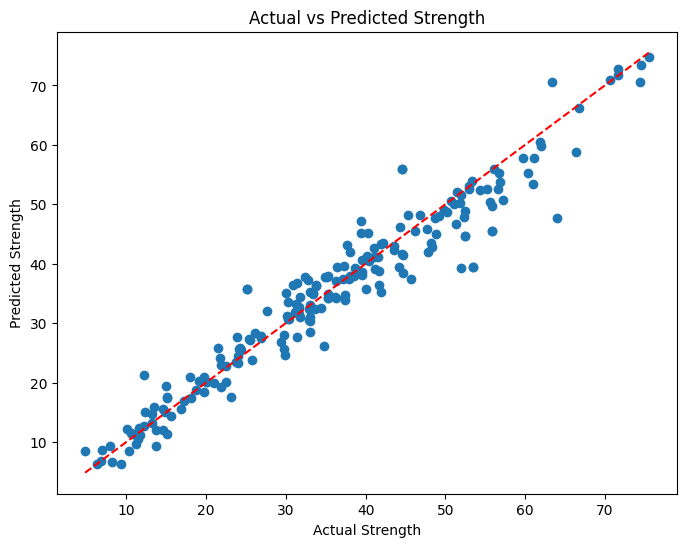

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted Strength")
plt.show()

### Actual vs Predicted Analysis

The points are concentrated around the diagonal line, indicating that the model predictions closely match the actual concrete strength values.

This suggests that the CatBoost model has learned the underlying patterns effectively and generalizes well on unseen data.

## Overfitting Analysis

To evaluate model generalization, the R² score was computed on both training and testing datasets.

- Training R² = 0.980
- Testing R² = 0.935

The relatively small gap between training and testing performance indicates that the model generalizes well to unseen data.

Although the training score is slightly higher than the testing score, the difference is not large enough to indicate severe overfitting.

Therefore, the CatBoost model demonstrates strong predictive performance while maintaining good generalization capability.

## Conclusion

After performing exploratory data analysis, preprocessing, and model evaluation, multiple regression algorithms were compared.

CatBoost Regressor achieved the best performance with:

- MAE = 2.84
- RMSE = 4.09
- R² = 0.935

The results indicate that concrete compressive strength depends on a combination of material composition and curing age.

Tree-based boosting methods significantly outperformed linear models, suggesting the presence of complex non-linear relationships among the features.

CatBoost was selected as the final model due to its superior predictive accuracy and strong generalization performance.

In [37]:
import pickle

with open("catboost_model.pkl", "wb") as f:
    pickle.dump(final_catboost, f)

In [38]:
import pickle

with open('preprocessor.pkl','wb') as f:
  pickle.dump(preprocessor,f)